# 5.5 — Convolutions, at the computer

Do the **pen-and-paper worksheet first**. Then this: your hand-computed kernels, let loose on
real-sized images. This is the C in CNN — the exact operation behind computer vision.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

# The honest-loops convolution — no library hiding the idea (this IS the lesson's Python)
def convolve(image, kernel):
    ih, iw = image.shape                    # .shape gives (rows, columns) — Module 2.6
    k = kernel.shape[0]
    out = np.zeros((ih - k + 1, iw - k + 1))          # the n-k+1 shrink rule
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = image[i:i+k, j:j+k]               # the window at (i, j)
            out[i, j] = np.sum(patch * kernel)        # dot product (Module 2.3 + 0.6)
    return out

## 1. Verify the lesson's hand computation

In [2]:
I = np.array([[1, 1, 1, 0, 0],
              [1, 1, 1, 0, 0],
              [1, 1, 1, 0, 0],
              [1, 1, 1, 0, 0],
              [1, 1, 1, 0, 0]], dtype=float)

K_vertical = np.array([[1, 0, -1],
                       [1, 0, -1],
                       [1, 0, -1]], dtype=float)

print(convolve(I, K_vertical))       # expect columns of 0, 3, 3 — your worksheet numbers
# Also check worksheet Part B: build its horizontal-edge image and kernel and convolve them here.

[[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]


## 2. A real canvas — a scene built from pure numpy

No photo files, no libraries: a sunrise over hills, painted with coordinate math
(`np.mgrid` gives every pixel its row/column coordinates — meshgrid's sibling).

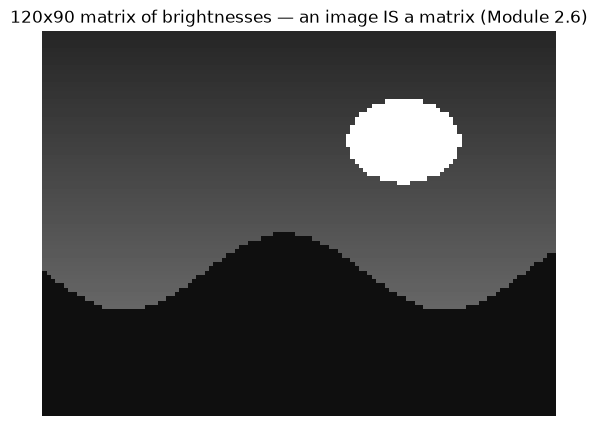

In [3]:
h, w = 90, 120
yy, xx = np.mgrid[0:h, 0:w]
yy, xx = yy / h, xx / w                       # scale coordinates to 0..1

scene = 0.15 + 0.35 * yy                                        # sky: brightening toward horizon
sun = (xx - 0.70)**2 + (yy - 0.28)**2 < 0.012                   # a circle (distance rule, M2.2)
scene[sun] = 1.0
ridge = 0.62 + 0.10 * np.sin(xx * 2 * np.pi * 1.6)              # a wavy hill line (M1.2 shapes)
scene = np.where(yy > ridge, 0.06, scene)                        # below the ridge: silhouetted hills

plt.figure(figsize=(7, 5))
plt.imshow(scene, cmap="gray", vmin=0, vmax=1)
plt.title("120x90 matrix of brightnesses — an image IS a matrix (Module 2.6)")
plt.axis("off")
plt.show()

## 3. The kernel gallery

Four detectives, each 9 numbers, each asked at every location: *are you here?*

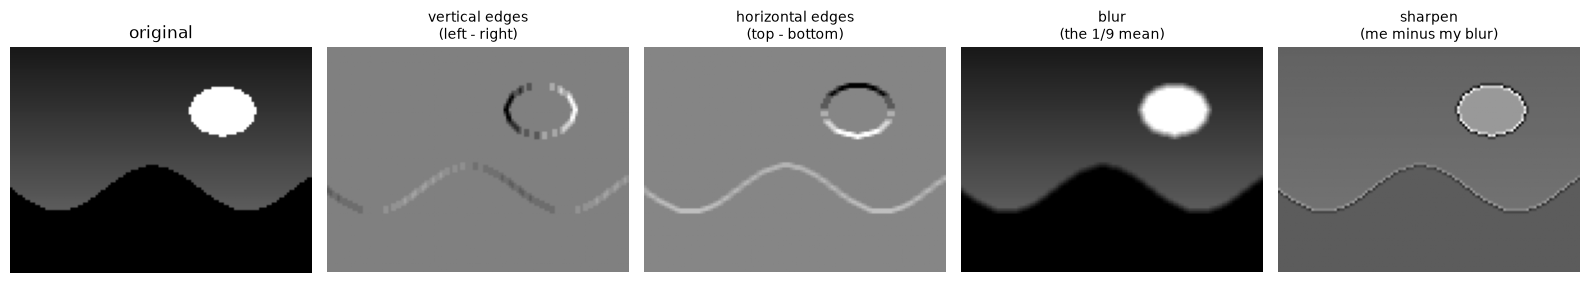

In [4]:
kernels = {
    "vertical edges\n(left - right)":  K_vertical,
    "horizontal edges\n(top - bottom)": np.array([[ 1,  1,  1], [ 0, 0, 0], [-1, -1, -1]], dtype=float),
    "blur\n(the 1/9 mean)":             np.ones((3, 3)) / 9,
    "sharpen\n(me minus my blur)":      np.array([[ 0, -1,  0], [-1, 5, -1], [ 0, -1,  0]], dtype=float),
}

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
axes[0].imshow(scene, cmap="gray"); axes[0].set_title("original")
for ax, (name, K) in zip(axes[1:], kernels.items()):
    ax.imshow(convolve(scene, K), cmap="gray")
    ax.set_title(name, fontsize=10)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
# Read them: vertical-edge finds the sun's SIDES, horizontal-edge finds the ridge and the sun's
# top/bottom, blur is worksheet D12 at scale, sharpen exaggerates every boundary.

## 4. The glow: edge magnitude

Vertical and horizontal responses are two components — treat them as a vector and take its
length (Module 2.1): $\sqrt{g_v^2 + g_h^2}$ = *edge strength regardless of direction*.
This is how outlines are found in real vision pipelines.

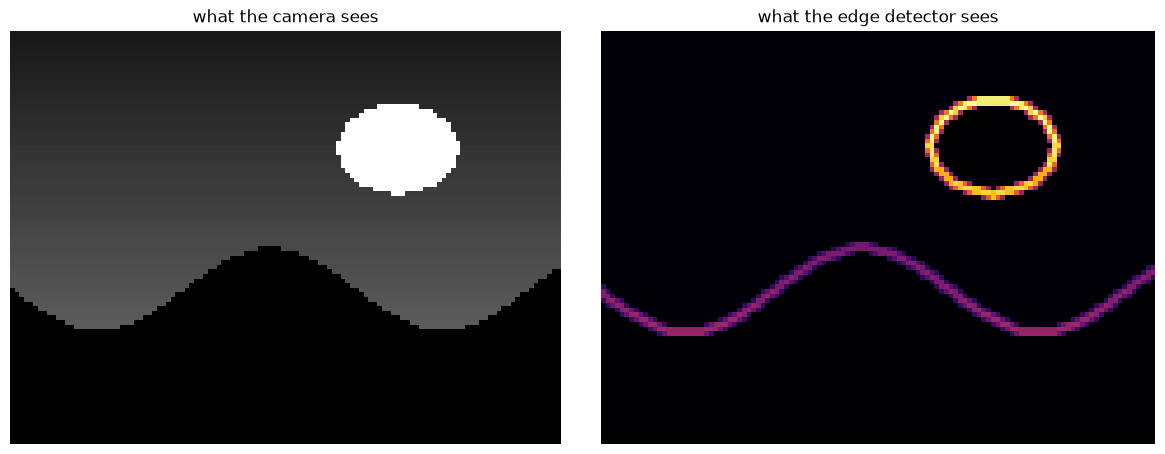

In [5]:
gv = convolve(scene, kernels["vertical edges\n(left - right)"])
gh = convolve(scene, kernels["horizontal edges\n(top - bottom)"])
magnitude = np.sqrt(gv**2 + gh**2)          # vector length at every pixel (Module 2.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(scene, cmap="gray"); axes[0].set_title("what the camera sees")
axes[1].imshow(magnitude, cmap="inferno"); axes[1].set_title("what the edge detector sees")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
# The scene, reduced to pure structure: sun rim and ridge line, glowing.
# A CNN's first layer learns kernels like these BY ITSELF — via 5.3's backprop —
# then feeds their outputs to more kernels: features of features (worksheet D15).

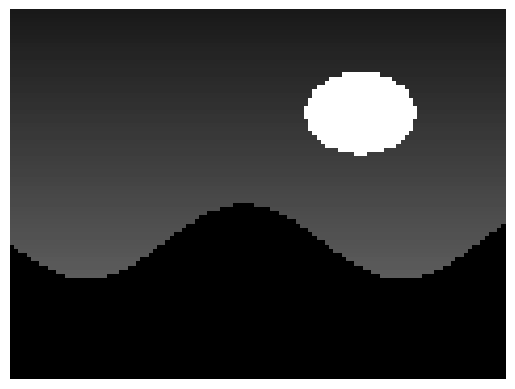

In [6]:
# YOUR TURN
# 1) Your worksheet D13 kernel (the lone-bright-pixel detector): define it and run it on `scene`.
#    Does it fire on the sun? Why is the sun not quite a "lone pixel"?

K_mine = np.array([[0, 0, 0],
                   [0, 1, 0],       # <- replace with your design
                   [0, 0, 0]], dtype=float)
plt.imshow(convolve(scene, K_mine), cmap="gray"); plt.axis("off"); plt.show()

# 2) Chain two convolutions: convolve(convolve(scene, blur), vertical_edge).
#    Compare with vertical_edge alone — why might a CNN want to blur BEFORE edge-finding?
# 3) Paint your own scene into a matrix (initials? a smiley?) and run the gallery on it.

## You are at the finish line

Forward pass, loss, backprop, training loop, convolutions — the complete mathematical anatomy of
a neural network, and every piece was a module you'd already beaten.

**Next: the boss worksheet — `06-boss-neural-net`. Cold, on paper, everything named.
Beat it and you are officially ready for fast.ai.**